In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/WELFake_Dataset.csv")

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.shape
df.columns
df["label"].value_counts()
df.isnull().sum()

df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
df = df.dropna(subset=["text"])
df.shape

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.drop(columns=["serial"], errors="ignore")

df.columns

Index(['title', 'text', 'label', 'content'], dtype='object')

In [5]:
df.to_csv("../data/processed/welfake_clean.csv", index=False)

df = pd.read_csv("../data/processed/welfake_clean.csv")

df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,NaN,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [6]:
X = df["content"]
y = df["label"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #ensure reproducibility-same split for every time
    stratify=y #keeps class balance consistent
)
X_train.to_csv("../data/splits/X_train.csv", index=False)
X_test.to_csv("../data/splits/X_test.csv", index=False)
y_train.to_csv("../data/splits/y_train.csv", index=False)
y_test.to_csv("../data/splits/y_test.csv", index=False)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7 #too common words ignored
)

X_train_tfidf = vectorizer.fit_transform(X_train) #fit -learn vocab, transform - convert to matrix
X_test_tfidf = vectorizer.transform(X_test) #no use of fit here-test data must remain unseen

In [9]:
X_train_tfidf.shape

(57676, 220275)

Logistic Regression

In [10]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

#make predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

#eval model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9489562382966918

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.94      0.96      0.95      7413

    accuracy                           0.95     14419
   macro avg       0.95      0.95      0.95     14419
weighted avg       0.95      0.95      0.95     14419



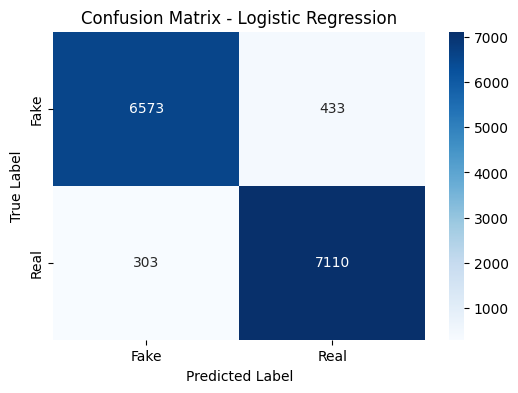

In [11]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../figures/confusion_matrix_lr.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
#ruajtja e modelit dhe vectorizer
import joblib

joblib.dump(log_reg, "../models/logistic_regression.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

Naive Bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8680907136417227

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      7006
           1       0.87      0.87      0.87      7413

    accuracy                           0.87     14419
   macro avg       0.87      0.87      0.87     14419
weighted avg       0.87      0.87      0.87     14419



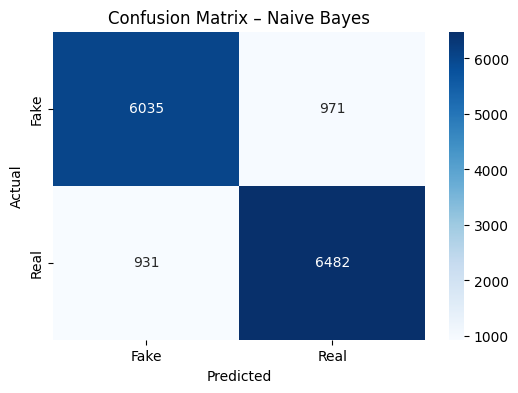

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix – Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/confusion_matrix_nb.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
import joblib

joblib.dump(nb_model, "../models/naive_bayes.pkl")


['../models/naive_bayes.pkl']

SVM- Support Vector Machine

In [16]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

#predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

/Users/beltinaa/fake-news-detection-thesis/venv/lib/python3.9/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM Accuracy: 0.9633816492128442

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      7006
           1       0.96      0.97      0.96      7413

    accuracy                           0.96     14419
   macro avg       0.96      0.96      0.96     14419
weighted avg       0.96      0.96      0.96     14419



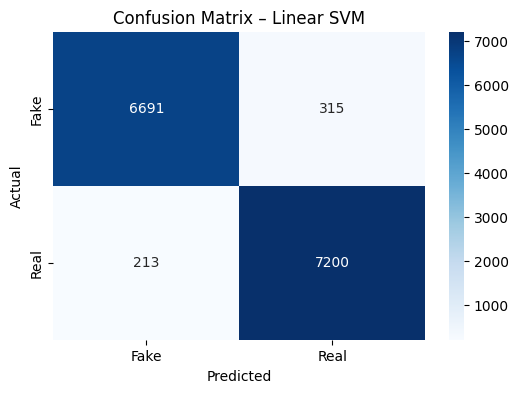

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix – Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
import joblib

joblib.dump(svm_model, "../models/linear_svm.pkl")

['../models/linear_svm.pkl']

Random Forest 

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9407725917192593

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7006
           1       0.93      0.96      0.94      7413

    accuracy                           0.94     14419
   macro avg       0.94      0.94      0.94     14419
weighted avg       0.94      0.94      0.94     14419



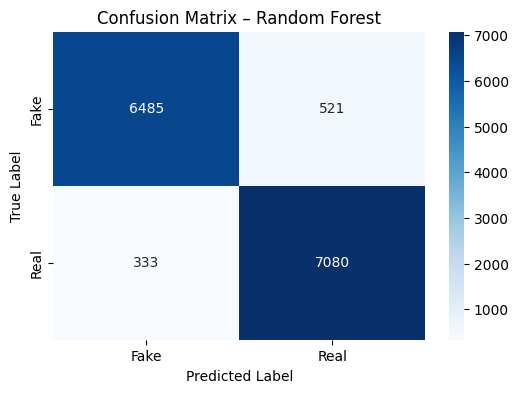

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("../figures/confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
import joblib

joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [22]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_nb,
        accuracy_svm,
        accuracy_rf
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Linear SVM,0.963382
0,Logistic Regression,0.948956
3,Random Forest,0.940773
1,Naive Bayes,0.868091


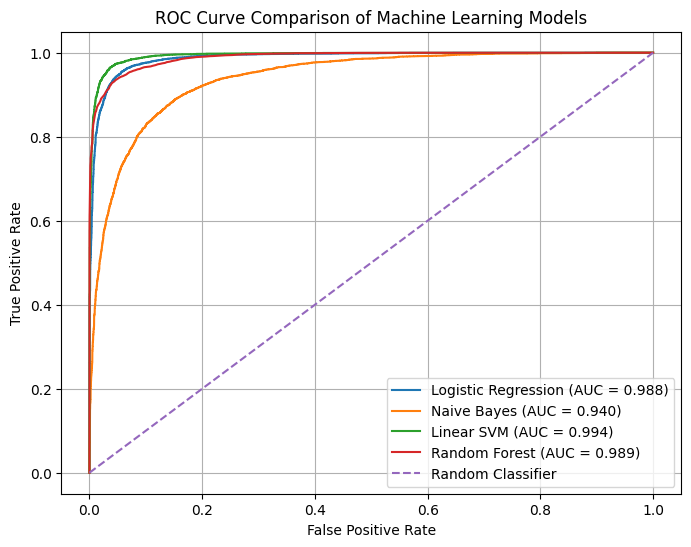

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability/score outputs
y_score_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]
y_score_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]
y_score_svm = svm_model.decision_function(X_test_tfidf) #SVM doesn't have predict_proba, use decision_function
y_score_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_score_nb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

# Compute AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_svm = auc(fpr_svm, tpr_svm)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"Linear SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.grid(True)

plt.savefig("../figures/roc_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score

print("LR classes:", log_reg.classes_)
print("NB classes:", nb_model.classes_)
print("SVM classes:", svm_model.classes_)
print("RF classes:", rf_model.classes_)

lr_idx = list(log_reg.classes_).index(1)
nb_idx = list(nb_model.classes_).index(1)
rf_idx = list(rf_model.classes_).index(1)

auc_lr_check = roc_auc_score(
    y_test,
    log_reg.predict_proba(X_test_tfidf)[:, lr_idx]
)

auc_nb_check = roc_auc_score(
    y_test,
    nb_model.predict_proba(X_test_tfidf)[:, nb_idx]
)

auc_svm_check = roc_auc_score(
    y_test,
    svm_model.decision_function(X_test_tfidf)
)

auc_rf_check = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_tfidf)[:, rf_idx]
)

print(f"LR AUC:  {auc_lr_check:.6f}")
print(f"NB AUC:  {auc_nb_check:.6f}")
print(f"SVM AUC: {auc_svm_check:.6f}")
print(f"RF AUC:  {auc_rf_check:.6f}")

LR classes: [0 1]
NB classes: [0 1]
SVM classes: [0 1]
RF classes: [0 1]
LR AUC:  0.987659
NB AUC:  0.939987
SVM AUC: 0.993618
RF AUC:  0.988861
